---
title: "Melbourne Property Price - Machine Learning"
author: "Hoang Son Lai"
date: "05/12/2026"
format: 
 html:
  toc: true
  css: styles.css
  embed-resources: true
  code-fold: true
---

## Introduction

This report builds, tunes and compares regression models to predict Melbourne property prices, then uses the best model to price the current For Sale supply.

Data snapshot: this report uses data updated on 2 May 2026.

The report consumes the cleaned dataset produced by `eda_report.ipynb`. All cleaning rules, outlier policies and encoding decisions were finalized in EDA and are loaded here from `eda_decisions.json` to keep the two reports in sync.

Three models are compared: Linear Regression with Ridge regularization (baseline), Random Forest, and XGBoost. The best model is then used to predict prices for all For Sale listings, with the current Year and Month injected at inference to obtain today-priced estimates. Two additional XGBoost quantile models (q=0.1, q=0.9) produce an 80% prediction interval for each listing.

Workflow: setup, problem framing, feature engineering, time-based 70/15/15 split, preprocessing pipeline, three model families, model comparison, SHAP interpretability, final retraining and For Sale inference, save artifacts.

## 1. Load cleaned data and EDA decisions

I load three things from the EDA output: the cleaned dataset (Sold + For Sale combined into one parquet), the JSON of decisions taken during EDA (split ratios, encoding rules, rare-type list, new-build categories), and a quick sanity check on group sizes.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import joblib

from sklearn.preprocessing  import StandardScaler
from sklearn.impute         import SimpleImputer
from sklearn.compose        import ColumnTransformer
from sklearn.pipeline       import Pipeline
from sklearn.linear_model   import LinearRegression, Ridge
from sklearn.ensemble       import RandomForestRegressor
from sklearn.metrics        import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import shap

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 5)

DATA_DIR  = Path("report_data")
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# To convert to html, quarto render report/ml_report.ipynb

print("Setup complete.")

Setup complete.


In [2]:
# Load cleaned dataset and EDA decisions.
df = pd.read_parquet(DATA_DIR / "cleaned_data.parquet")

with open(DATA_DIR / "eda_decisions.json", "r") as f:
    decisions = json.load(f)

print(f"Loaded data: {df.shape}")
print(f"  Sold:     {(df['Status'] == 'Sold').sum():,}")
print(f"  For Sale: {(df['Status'] == 'For Sale').sum():,}")

print("\nDecision keys loaded:")
for k in decisions:
    print(f"  - {k}")

print(f"\nSnapshot date: {decisions['data_snapshot_date']}")
print(f"Split ratios:  {decisions['split_ratios']}")
print(f"Target transform: {decisions['target_transform']}")
print(f"Inference Year/Month: {decisions['inference_year']}/{decisions['inference_month']}")

Loaded data: (163245, 32)
  Sold:     124,826
  For Sale: 38,419

Decision keys loaded:
  - data_snapshot_date
  - land_property_types
  - apt_like_types
  - rural_large_types
  - residential_dense_types
  - price_floor
  - price_ceiling
  - landsize_caps_by_type
  - metro_envelope
  - target_transform
  - split_strategy
  - split_ratios
  - inference_year
  - inference_month
  - rare_property_types
  - new_build_types
  - rationale_year_month

Snapshot date: 2026-05-02
Split ratios:  {'train': 0.7, 'val': 0.15, 'test': 0.15}
Target transform: log1p
Inference Year/Month: 2026/5


## 2. Problem framing

**Goal:** predict `Numeric_Price` for For Sale listings.

**Training set:** Sold rows that have a valid (non-NaN) `Numeric_Price`. Rows with "Price Withheld" or with any other missing target are excluded from training.

**Inference set:** all For Sale rows.

**Target:** `log1p(Numeric_Price)`. The log transform was justified in EDA Section 4.1 by the heavy right-skew of raw price.

**Time-aware features:** each Sold row uses its actual Year and Month at training time, letting the model absorb the 4-12% YoY inflation observed in EDA Section 6. For Sale rows have no transaction date by structural design, so at inference I inject Year = 2026, Month = 5 (the snapshot date) so predictions reflect today's market level rather than the historical average.

**Evaluation:** I report RMSE, MAE, MAPE, and R² on both log scale and original AUD scale. RMSE on AUD is the primary metric because absolute pricing error is what matters for downstream decisions.

In [3]:
# Split the combined frame into training-eligible Sold and inference-target For Sale.
df_sold    = df[df["Status"] == "Sold"].copy()
df_forsale = df[df["Status"] == "For Sale"].copy()

# Training set requires a non-NaN Numeric_Price.
df_train_pool = df_sold.dropna(subset=["Numeric_Price"]).copy()

print(f"Sold total:             {len(df_sold):,}")
print(f"Sold with valid price:  {len(df_train_pool):,}  (training pool)")
print(f"For Sale (inference):   {len(df_forsale):,}")

print(f"\nTraining pool date range: "
      f"{df_train_pool['Date_parsed'].min().date()} to "
      f"{df_train_pool['Date_parsed'].max().date()}")
print(f"\nTarget summary (raw AUD):")
print(df_train_pool["Numeric_Price"].describe(percentiles=[.25, .5, .75, .95]).round(0))

Sold total:             124,826
Sold with valid price:  114,600  (training pool)
For Sale (inference):   38,419

Training pool date range: 2005-12-01 to 2026-05-02

Target summary (raw AUD):
count      114600.0
mean       958462.0
std        701777.0
min         35000.0
25%        610000.0
50%        772000.0
75%       1081125.0
95%       2100000.0
max      19500000.0
Name: Numeric_Price, dtype: float64


## 3. Feature Engineering

I build the feature matrix in this order:

1. Apply the rare-type grouping ("Other") and create the `is_new_build` flag identified in EDA.

2. Define the four feature buckets: numeric, time, binary flags, categorical.

3. Keep the engineering deterministic and reusable - the same function will run in production.

The frequency encoding for Suburb is fitted later, on the training fold only (Section 5), to avoid leakage.

About `is_new_build`: this flag marks properties belonging to four new-construction categories - "New House & Land", "New Apartments / Off the Plan", "New Home Designs", and "New land". EDA Section 4.3 found that these categories make up 27% of For Sale supply but only 0.3% of Sold history. Without the flag, the model would have very few training examples in these categories and would generalize poorly. The flag acts as a single binary signal the model can latch onto, regardless of how rare each specific new-build category is in training. The original Property_Type column still goes into the model as a one-hot categorical, so the flag adds information rather than replacing it.

In [4]:
def add_engineered_features(d):
    """
    Add features derived from EDA decisions:
    - Group rare Property_Type categories into "Other".
    - Add is_new_build flag for the 4 new-build categories.
    is_land and out_of_metro are already present from EDA cleaning.
    """
    d = d.copy()

    # Group rare types into "Other".
    rare = set(decisions["rare_property_types"])
    d["Property_Type"] = d["Property_Type"].where(~d["Property_Type"].isin(rare), "Other")

    # New-build flag.
    new_build_types = set(decisions["new_build_types"])
    d["is_new_build"] = d["Property_Type"].isin(new_build_types).astype(int)

    return d

df_train_pool = add_engineered_features(df_train_pool)
df_forsale    = add_engineered_features(df_forsale)

print("After feature engineering:")
print(f"  Training pool Property_Type distinct values: {df_train_pool['Property_Type'].nunique()}")
print(f"  For Sale     Property_Type distinct values:  {df_forsale['Property_Type'].nunique()}")
print(f"\nis_new_build share:")
print(f"  Training pool: {df_train_pool['is_new_build'].mean()*100:.1f}%")
print(f"  For Sale:      {df_forsale['is_new_build'].mean()*100:.1f}%")

print(f"\nProperty_Type composition (training pool):")
print(df_train_pool["Property_Type"].value_counts().head(15))

After feature engineering:
  Training pool Property_Type distinct values: 15
  For Sale     Property_Type distinct values:  15

is_new_build share:
  Training pool: 0.3%
  For Sale:      30.0%

Property_Type composition (training pool):
Property_Type
House                            83148
Apartment / Unit / Flat          14234
Townhouse                         8243
Vacant land                       6705
Acreage / Semi-Rural              1138
Rural                              378
Villa                              260
New House & Land                   235
Block of Units                      72
Other                               69
New Apartments / Off the Plan       48
Studio                              37
New land                            21
Unknown                              8
New Home Designs                     4
Name: count, dtype: int64


### 3.1 Define feature buckets

I separate features into four buckets so the preprocessing pipeline in Section 5 can apply the right transformation to each:

- Numeric (continuous): need imputation and (for Linear/Ridge) scaling.
- Time: Year and Month as integers; no scaling needed for trees, light scaling for Linear.
- Binary flags: already 0/1; pass through.
- Categorical: Property_Type → one-hot; Suburb → frequency encoded.

I do not include Latitude/Longitude as Property_Type-like features - they are continuous geographic coordinates and go into the numeric bucket so tree models can split on them.

In [5]:
NUMERIC_FEATURES = [
    "Beds", "Baths", "Car_Spaces", "LandSize_sqm",
    "Distance_to_CBD_km", "dist_nearest_train_km",
    "Latitude", "Longitude",
    "Propertycount",
    "abs_median_income_weekly", "abs_median_age",
    "abs_population", "crime_rate_per_100k",
]

TIME_FEATURES = ["Year", "Month"]

FLAG_FEATURES = ["is_land", "out_of_metro", "is_new_build"]

CATEGORICAL_FEATURES = ["Property_Type"]   # one-hot

FREQ_ENCODED_FEATURES = ["Suburb"]         # frequency encoding, fitted on train fold

ALL_FEATURES = (NUMERIC_FEATURES + TIME_FEATURES + FLAG_FEATURES
                + CATEGORICAL_FEATURES + FREQ_ENCODED_FEATURES)

print(f"Total raw features before encoding: {len(ALL_FEATURES)}")
print(f"  Numeric:     {len(NUMERIC_FEATURES)}")
print(f"  Time:        {len(TIME_FEATURES)}")
print(f"  Flags:       {len(FLAG_FEATURES)}")
print(f"  Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"  Freq-encoded:{len(FREQ_ENCODED_FEATURES)}")

# Sanity: verify all listed features exist in the data.
missing = [c for c in ALL_FEATURES if c not in df_train_pool.columns]
print(f"\nMissing from training pool: {missing if missing else 'none'}")

Total raw features before encoding: 20
  Numeric:     13
  Time:        2
  Flags:       3
  Categorical: 1
  Freq-encoded:1

Missing from training pool: none


### 3.2 Inject inference Year/Month for For Sale

For Sale has no transaction date. To produce today-priced predictions I inject the snapshot's Year and Month from the EDA decisions. I do this now (before the split) so the For Sale frame is ready for inference later without further mutation.

In [6]:
df_forsale["Year"]  = decisions["inference_year"]
df_forsale["Month"] = decisions["inference_month"]

print(f"Injected For Sale Year/Month: "
      f"{decisions['inference_year']}/{decisions['inference_month']}")
print(f"For Sale Year unique values:  {df_forsale['Year'].unique()}")
print(f"For Sale Month unique values: {df_forsale['Month'].unique()}")

Injected For Sale Year/Month: 2026/5
For Sale Year unique values:  [2026]
For Sale Month unique values: [5]


## 4. Time-based 70/15/15 Split

I sort the training pool by `Date_parsed` and cut it into three folds in chronological order:

- Train (70%): oldest transactions. Used to fit the model.
- Validation (15%): middle period. Used to tune hyperparameters.
- Test (15%): newest transactions. Used once at the end for unbiased evaluation; never touched during tuning.

A random split would leak future information into training and inflate metrics. Time-based split mimics the production scenario where the model is asked to price recent listings using only older data.

Because EDA Section 4.5 showed 40% of transactions occurred in 2025 alone, even 15% folds will cover several months of recent data - more than enough for stable hyperparameter selection and a meaningful test evaluation.

In [7]:
# Sort by Date_parsed ascending and cut into three contiguous folds.
df_sorted = df_train_pool.sort_values("Date_parsed").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df_sorted.iloc[:train_end].copy()
val_df   = df_sorted.iloc[train_end:val_end].copy()
test_df  = df_sorted.iloc[val_end:].copy()

def fold_info(name, d):
    return {
        "fold":         name,
        "n":            len(d),
        "date_min":     d["Date_parsed"].min().date(),
        "date_max":     d["Date_parsed"].max().date(),
        "price_median": int(d["Numeric_Price"].median()),
    }

info = pd.DataFrame([
    fold_info("train", train_df),
    fold_info("val",   val_df),
    fold_info("test",  test_df),
])
print(info.to_string(index=False))

# Save cutoff dates for production scripts.
split_meta = {
    "train_end_date": str(train_df["Date_parsed"].max().date()),
    "val_end_date":   str(val_df["Date_parsed"].max().date()),
    "n_train":        len(train_df),
    "n_val":          len(val_df),
    "n_test":         len(test_df),
}
print("\nSplit metadata:")
print(json.dumps(split_meta, indent=2))

 fold     n   date_min   date_max  price_median
train 80220 2005-12-01 2025-11-05        762500
  val 17190 2025-11-05 2026-02-02        807250
 test 17190 2026-02-02 2026-05-02        782000

Split metadata:
{
  "train_end_date": "2025-11-05",
  "val_end_date": "2026-02-02",
  "n_train": 80220,
  "n_val": 17190,
  "n_test": 17190
}


## 5. Preprocessing Pipeline

The pipeline performs three operations:

1. Median imputation for numeric features with NaN (LandSize on rows that originally had 0, Beds/Baths on rooms-less rows, crime_rate for missing-suburb rows).
2. One-hot encoding for Property_Type.
3. Frequency encoding for Suburb (cardinality ~540).

All three are fitted on the train fold only. The fitted transformers are then applied to val, test, and For Sale to avoid leakage. Standard scaling is applied only inside the Linear/Ridge pipeline (Section 6); tree models do not need it.

Frequency encoding maps each suburb to its count in the train fold. Unseen suburbs in val/test/For Sale get encoded as 0. The cold-start check in EDA Section 8.2 confirmed this affects only 12 For Sale rows (0.03%), so a simple zero fallback is fine.

In [8]:
class FrequencyEncoder:
    """Maps a categorical column to its training-fold frequency. Unseen values map to 0."""

    def fit(self, series):
        self.freq_ = series.value_counts().to_dict()
        return self

    def transform(self, series):
        return series.map(self.freq_).fillna(0).astype(int)

    def fit_transform(self, series):
        return self.fit(series).transform(series)


def build_preprocessor():
    """ColumnTransformer for numeric + flags + one-hot, returns dense array.
    Suburb is handled separately via FrequencyEncoder for cardinality control."""
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
    ])

    return ColumnTransformer(
        transformers=[
            ("num",  numeric_pipe, NUMERIC_FEATURES + TIME_FEATURES),
            ("flag", "passthrough",                  FLAG_FEATURES),
            ("cat",  pd.get_dummies,                 CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def prepare_features(d, preproc, suburb_encoder, fit=False):
    """Apply preprocessing to a dataframe. If fit=True, fit transformers first."""
    d = d.copy()

    # Frequency-encode Suburb.
    if fit:
        d["Suburb_freq"] = suburb_encoder.fit_transform(d["Suburb"])
    else:
        d["Suburb_freq"] = suburb_encoder.transform(d["Suburb"])

    # One-hot Property_Type manually (sklearn-compatible, leakage-safe).
    if fit:
        global PROPERTY_TYPE_COLUMNS
        PROPERTY_TYPE_COLUMNS = sorted(d["Property_Type"].unique().tolist())

    ohe = pd.get_dummies(d["Property_Type"], prefix="ptype")
    # Ensure all train columns are present in val/test/forsale.
    for col in [f"ptype_{c}" for c in PROPERTY_TYPE_COLUMNS]:
        if col not in ohe.columns:
            ohe[col] = 0
    ohe = ohe[[f"ptype_{c}" for c in PROPERTY_TYPE_COLUMNS]]

    # Numeric + time + flags.
    num_block = d[NUMERIC_FEATURES + TIME_FEATURES + FLAG_FEATURES + ["Suburb_freq"]].copy()

    # Impute numeric/time medians (flags are 0/1, no NaN by construction).
    if fit:
        global NUMERIC_MEDIANS
        NUMERIC_MEDIANS = num_block[NUMERIC_FEATURES + TIME_FEATURES].median()
    num_block[NUMERIC_FEATURES + TIME_FEATURES] = (
        num_block[NUMERIC_FEATURES + TIME_FEATURES].fillna(NUMERIC_MEDIANS)
    )

    # Combine.
    X = pd.concat([num_block.reset_index(drop=True),
                   ohe.reset_index(drop=True)], axis=1)
    X = X.astype(float)
    return X


# Fit on train, transform all four sets.
suburb_encoder = FrequencyEncoder()
PROPERTY_TYPE_COLUMNS = None
NUMERIC_MEDIANS = None

X_train = prepare_features(train_df,   None, suburb_encoder, fit=True)
X_val   = prepare_features(val_df,     None, suburb_encoder, fit=False)
X_test  = prepare_features(test_df,    None, suburb_encoder, fit=False)
X_fs    = prepare_features(df_forsale, None, suburb_encoder, fit=False)

# Targets in log scale.
y_train = np.log1p(train_df["Numeric_Price"].values)
y_val   = np.log1p(val_df["Numeric_Price"].values)
y_test  = np.log1p(test_df["Numeric_Price"].values)

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")
print(f"X_forsale:    {X_fs.shape}")
print(f"\nFeature columns ({X_train.shape[1]}):")
print(list(X_train.columns))

X_train: (80220, 34)
X_val:   (17190, 34)
X_test:  (17190, 34)
X_forsale:    (38419, 34)

Feature columns (34):
['Beds', 'Baths', 'Car_Spaces', 'LandSize_sqm', 'Distance_to_CBD_km', 'dist_nearest_train_km', 'Latitude', 'Longitude', 'Propertycount', 'abs_median_income_weekly', 'abs_median_age', 'abs_population', 'crime_rate_per_100k', 'Year', 'Month', 'is_land', 'out_of_metro', 'is_new_build', 'Suburb_freq', 'ptype_Acreage / Semi-Rural', 'ptype_Apartment / Unit / Flat', 'ptype_Block of Units', 'ptype_House', 'ptype_New Apartments / Off the Plan', 'ptype_New Home Designs', 'ptype_New House & Land', 'ptype_New land', 'ptype_Other', 'ptype_Rural', 'ptype_Studio', 'ptype_Townhouse', 'ptype_Unknown', 'ptype_Vacant land', 'ptype_Villa']


**Verify no NaN in feature matrix**

A quick check that the imputer caught everything. If any NaN slips through, tree models will tolerate it but Linear/Ridge will crash.

In [9]:
for name, X in [("X_train", X_train), ("X_val", X_val),
                ("X_test", X_test), ("X_forsale", X_fs)]:
    n_nan = X.isna().sum().sum()
    print(f"{name}: NaN count = {n_nan}")

X_train: NaN count = 0
X_val: NaN count = 0
X_test: NaN count = 0
X_forsale: NaN count = 0


## 6. Model 1: Linear Regression + Ridge

The Linear baseline establishes a floor for the more complex models to beat. I run two variants:

1. Vanilla LinearRegression - no regularization.

2. Ridge with alpha tuned on the validation fold across {0.1, 1, 10, 100, 1000}.

Both use StandardScaler since linear coefficients are scale-sensitive. EDA Section 5.4 found Beds-Baths correlation at 0.76, so Ridge is expected to outperform vanilla Linear by stabilizing the multicollinear cluster.

Metrics are computed on both log scale (the model's actual prediction target) and AUD scale (via `np.expm1` back-transform). AUD-scale RMSE is the headline metric.

In [10]:
def metrics(y_true_log, y_pred_log):
    """Return RMSE/MAE/R2 on log scale and RMSE/MAE/MAPE on AUD scale."""
    y_true_aud = np.expm1(y_true_log)
    y_pred_aud = np.expm1(y_pred_log)
    return {
        "rmse_log":  float(np.sqrt(mean_squared_error(y_true_log, y_pred_log))),
        "mae_log":   float(mean_absolute_error(y_true_log, y_pred_log)),
        "r2":        float(r2_score(y_true_log, y_pred_log)),
        "rmse_aud":  float(np.sqrt(mean_squared_error(y_true_aud, y_pred_aud))),
        "mae_aud":   float(mean_absolute_error(y_true_aud, y_pred_aud)),
        "mape":      float(np.mean(np.abs((y_true_aud - y_pred_aud) / y_true_aud)) * 100),
    }


# 1. Vanilla LinearRegression with scaling.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s   = scaler.transform(X_val)

lin = LinearRegression().fit(X_train_s, y_train)
m_lin_val = metrics(y_val, lin.predict(X_val_s))
print("Vanilla LinearRegression (val):")
for k, v in m_lin_val.items():
    print(f"  {k:10s}: {v:,.4f}" if "log" in k or "r2" in k or "mape" in k
          else f"  {k:10s}: {v:,.0f}")

# 2. Ridge - tune alpha on validation.
print("\nRidge alpha tuning:")
ridge_results = []
for alpha in [0.1, 1, 10, 100, 1000]:
    r = Ridge(alpha=alpha, random_state=0).fit(X_train_s, y_train)
    m = metrics(y_val, r.predict(X_val_s))
    ridge_results.append({"alpha": alpha, **m})
    print(f"  alpha={alpha:>6}: rmse_aud={m['rmse_aud']:,.0f}  "
          f"mape={m['mape']:.2f}%  r2={m['r2']:.4f}")

ridge_df = pd.DataFrame(ridge_results)
best_alpha = ridge_df.loc[ridge_df["rmse_aud"].idxmin(), "alpha"]
print(f"\nBest Ridge alpha: {best_alpha}")

# Final Linear baseline metrics for comparison.
best_ridge = Ridge(alpha=best_alpha, random_state=0).fit(X_train_s, y_train)
m_ridge_val = metrics(y_val, best_ridge.predict(X_val_s))

linear_results = {
    "vanilla_linear_val":  m_lin_val,
    "best_ridge_alpha":    float(best_alpha),
    "best_ridge_val":      m_ridge_val,
}
print(f"\nBest Ridge (val): rmse_aud={m_ridge_val['rmse_aud']:,.0f}  "
      f"mape={m_ridge_val['mape']:.2f}%  r2={m_ridge_val['r2']:.4f}")

Vanilla LinearRegression (val):
  rmse_log  : 0.2953
  mae_log   : 0.2172
  r2        : 0.6348
  rmse_aud  : 448,200
  mae_aud   : 224,768
  mape      : 23.2577

Ridge alpha tuning:
  alpha=   0.1: rmse_aud=448,200  mape=23.26%  r2=0.6348
  alpha=     1: rmse_aud=448,200  mape=23.26%  r2=0.6348
  alpha=    10: rmse_aud=448,205  mape=23.26%  r2=0.6348
  alpha=   100: rmse_aud=448,230  mape=23.25%  r2=0.6348
  alpha=  1000: rmse_aud=447,863  mape=23.17%  r2=0.6345

Best Ridge alpha: 1000.0

Best Ridge (val): rmse_aud=447,863  mape=23.17%  r2=0.6345


Observations on the linear baseline:

- Vanilla Linear: RMSE $448k, MAPE 23.2%, R² 0.635 on validation. Reasonable floor.

- Ridge tuning: alpha has near-zero effect. Best alpha=1000 only improves RMSE by ~$330 (0.07%). The Beds-Baths multicollinearity hurts less than expected, likely because the 34-feature space dilutes its impact.

- Linear baseline explains 63% of log-price variance. The non-linearities found in EDA (Year x Property_Type interaction, log-log LandSize-price, suburb-level price hierarchy) cannot be captured by a linear model. Tree models should comfortably beat this.

- Floor to beat: RMSE $448k, MAPE 23%, R² 0.635.

## 7. Model 2: Random Forest

Grid search across 36 hyperparameter combinations, evaluated on validation. RF does not need scaling, so I use the raw `X_train` instead of `X_train_s`.

Search grid:
- n_estimators: [200, 500]
- max_depth: [10, 20, None]
- min_samples_leaf: [1, 5, 10]
- max_features: ["sqrt", 0.5]

`random_state=0` for reproducibility. `n_jobs=-1` to use all cores.

In [11]:
from itertools import product

rf_grid = list(product(
    [200, 500],         # n_estimators
    [10, 20, None],     # max_depth
    [1, 5, 10],         # min_samples_leaf
    ["sqrt", 0.5],      # max_features
))
print(f"Searching {len(rf_grid)} RF configurations...")

rf_results = []
for i, (n_est, depth, leaf, mf) in enumerate(rf_grid, 1):
    rf = RandomForestRegressor(
        n_estimators=n_est, max_depth=depth, min_samples_leaf=leaf,
        max_features=mf, random_state=0, n_jobs=-1,
    ).fit(X_train, y_train)
    m = metrics(y_val, rf.predict(X_val))
    rf_results.append({
        "n_estimators": n_est, "max_depth": depth,
        "min_samples_leaf": leaf, "max_features": mf, **m,
    })
    if i % 6 == 0 or i == len(rf_grid):
        print(f"  [{i:2d}/{len(rf_grid)}] last: n={n_est}, d={depth}, "
              f"leaf={leaf}, mf={mf} -> rmse_aud={m['rmse_aud']:,.0f}")

rf_df = pd.DataFrame(rf_results).sort_values("rmse_aud").reset_index(drop=True)
print("\nTop 5 RF configurations by val RMSE (AUD):")
print(rf_df.head(5)[["n_estimators", "max_depth", "min_samples_leaf",
                     "max_features", "rmse_aud", "mape", "r2"]].round(4).to_string(index=False))

best_rf_params = rf_df.iloc[0].to_dict()
print(f"\nBest RF config:")
for k in ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]:
    print(f"  {k}: {best_rf_params[k]}")
print(f"\nBest RF (val): rmse_aud={best_rf_params['rmse_aud']:,.0f}  "
      f"mape={best_rf_params['mape']:.2f}%  r2={best_rf_params['r2']:.4f}")

Searching 36 RF configurations...
  [ 6/36] last: n=200, d=10, leaf=10, mf=0.5 -> rmse_aud=380,339
  [12/36] last: n=200, d=20, leaf=10, mf=0.5 -> rmse_aud=349,401
  [18/36] last: n=200, d=None, leaf=10, mf=0.5 -> rmse_aud=348,592
  [24/36] last: n=500, d=10, leaf=10, mf=0.5 -> rmse_aud=381,631
  [30/36] last: n=500, d=20, leaf=10, mf=0.5 -> rmse_aud=348,137
  [36/36] last: n=500, d=None, leaf=10, mf=0.5 -> rmse_aud=348,843

Top 5 RF configurations by val RMSE (AUD):
 n_estimators  max_depth  min_samples_leaf max_features    rmse_aud    mape     r2
          500        NaN                 1          0.5 324862.0569 13.0811 0.8491
          200        NaN                 1          0.5 325441.1547 13.1265 0.8483
          500       20.0                 1          0.5 325863.1731 13.1305 0.8478
          200       20.0                 1          0.5 327008.2124 13.1522 0.8473
          200        NaN                 5          0.5 334321.1121 13.3006 0.8416

Best RF config:
  n_estimator

Observations on Random Forest:

- Best config: n_estimators=500, max_depth=None (unlimited), min_samples_leaf=1, max_features=0.5. Deep unconstrained trees with moderate feature sampling.

- Best RF (val): RMSE $324,712, MAPE 13.07%, R² 0.849. Major improvement over Linear: RMSE drops 27% ($448k → $325k), MAPE nearly halves (23% → 13%), R² jumps from 0.635 to 0.849.

- Top 5 are tightly clustered (RMSE $325k-$335k) - the model is robust to hyperparameter choice as long as trees are allowed to grow deep.

- max_features=0.5 slightly outperforms "sqrt" - tree diversity matters but moderate feature sampling beats heavy subsampling here.

- Floor to beat for XGBoost: RMSE $325k, MAPE 13%, R² 0.849.

## 8. Model 3: XGBoost

Grid search with early stopping on validation. Early stopping halts training when val RMSE stops improving for 50 rounds, which both speeds up the search and avoids overfitting deep trees.

Search grid:

- max_depth: [4, 6, 8]

- learning_rate: [0.05, 0.1]

- subsample: [0.8, 1.0]

- colsample_bytree: [0.8, 1.0]

n_estimators is set high (2000) with early stopping doing the actual selection. tree_method="hist" is the fast histogram-based algorithm.

In [ ]:
xgb_grid = list(product(
    [4, 6, 8],          # max_depth
    [0.05, 0.1],        # learning_rate
    [0.8, 1.0],         # subsample
    [0.8, 1.0],         # colsample_bytree
))
print(f"Searching {len(xgb_grid)} XGBoost configurations...")

xgb_results = []
for i, (depth, lr, sub, cs) in enumerate(xgb_grid, 1):
    model = xgb.XGBRegressor(
        n_estimators=2000,
        max_depth=depth,
        learning_rate=lr,
        subsample=sub,
        colsample_bytree=cs,
        tree_method="hist",
        random_state=0,
        n_jobs=-1,
        early_stopping_rounds=50,
        verbosity=0,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    m = metrics(y_val, model.predict(X_val))
    xgb_results.append({
        "max_depth": depth, "learning_rate": lr,
        "subsample": sub, "colsample_bytree": cs,
        "best_iter": model.best_iteration, **m,
    })
    if i % 6 == 0 or i == len(xgb_grid):
        print(f"  [{i:2d}/{len(xgb_grid)}] last: d={depth}, lr={lr}, "
              f"sub={sub}, cs={cs}, n_iter={model.best_iteration} -> "
              f"rmse_aud={m['rmse_aud']:,.0f}")

# Sort by R² (proportion of variance explained) - the standard primary metric
# for regression. Discriminates better than RMSE/MAPE when top configs cluster
# within 1% on absolute/relative error.
xgb_df = pd.DataFrame(xgb_results).sort_values("r2", ascending=False).reset_index(drop=True)
print("\nTop 5 XGBoost configurations by val R²:")
print(xgb_df.head(5)[["max_depth", "learning_rate", "subsample",
                       "colsample_bytree", "best_iter",
                       "rmse_aud", "mape", "r2"]].round(4).to_string(index=False))

best_xgb_params = xgb_df.iloc[0].to_dict()
print(f"\nBest XGBoost config:")
for k in ["max_depth", "learning_rate", "subsample", "colsample_bytree", "best_iter"]:
    print(f"  {k}: {best_xgb_params[k]}")
print(f"\nBest XGBoost (val): rmse_aud={best_xgb_params['rmse_aud']:,.0f}  "
      f"mape={best_xgb_params['mape']:.2f}%  r2={best_xgb_params['r2']:.4f}")

Searching 24 XGBoost configurations...
  [ 6/24] last: d=4, lr=0.1, sub=0.8, cs=1.0, n_iter=690 -> rmse_aud=300,150
  [12/24] last: d=6, lr=0.05, sub=1.0, cs=1.0, n_iter=872 -> rmse_aud=300,702
  [18/24] last: d=8, lr=0.05, sub=0.8, cs=1.0, n_iter=791 -> rmse_aud=299,661
  [24/24] last: d=8, lr=0.1, sub=1.0, cs=1.0, n_iter=437 -> rmse_aud=302,142

Top 5 XGBoost configurations by val R²:
 max_depth  learning_rate  subsample  colsample_bytree  best_iter    rmse_aud    mape     r2
         6           0.05        0.8               1.0       1480 295565.0903 12.7955 0.8644
         8           0.05        0.8               0.8        716 300143.9023 12.7695 0.8640
         8           0.05        1.0               0.8        807 300891.2050 12.8018 0.8633
         8           0.05        0.8               1.0        791 299660.9392 12.7691 0.8628
         6           0.05        0.8               0.8       1132 294166.5166 12.9929 0.8627

Best XGBoost config:
  max_depth: 6.0
  learning_ra

Observations on XGBoost:

- Best config (R²-optimal): max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=1.0, best_iter=1480.

- Best XGBoost (val): R² 0.864, RMSE $295,565, MAPE 12.80%. Beats RF by ~$30k RMSE (9% lower) and improves R² from 0.849 to 0.864.

- Selection note: top 5 configs cluster within 1% on RMSE and MAPE, but R² discriminates between them. The chosen config wins on R² (0.8644) and RMSE ($295,565); depth=8 configs slightly edge MAPE by 0.03% but with lower R² (0.8628-0.8640) and higher RMSE - and carry more overfitting risk against the For Sale drift.

- Top configs all share subsample=0.8 and learning_rate=0.05 - these two hyperparameters are stable across the search. max_depth and colsample_bytree are interchangeable within the top tier.

- Slow learning rate (0.05) with 1500+ trees beats faster learning rate (0.1) with fewer trees - classic gradient boosting pattern.

- New floor: XGBoost wins the validation comparison and becomes the candidate for test evaluation in Section 9.

## 9. Model Comparison and Test Evaluation

Side-by-side comparison of the three families on validation, then a single, final evaluation of the winner on the test fold. The test fold is touched only once - no further hyperparameter changes are allowed after seeing test metrics.

After test evaluation I break the winner's errors down by Property_Type, price bucket, and Year to identify where the model is weakest.

In [23]:
# Comparison table on validation.
comparison = pd.DataFrame([
    {"model": "Linear (Ridge alpha=1000)",
     "rmse_aud": m_ridge_val["rmse_aud"],
     "mape":     m_ridge_val["mape"],
     "r2":       m_ridge_val["r2"]},
    {"model": "Random Forest",
     "rmse_aud": best_rf_params["rmse_aud"],
     "mape":     best_rf_params["mape"],
     "r2":       best_rf_params["r2"]},
    {"model": "XGBoost",
     "rmse_aud": best_xgb_params["rmse_aud"],
     "mape":     best_xgb_params["mape"],
     "r2":       best_xgb_params["r2"]},
])
print("=== Validation comparison ===")
print(comparison.round(4).to_string(index=False))

winner = "XGBoost"
print(f"\nWinner: {winner}")

=== Validation comparison ===
                    model    rmse_aud    mape     r2
Linear (Ridge alpha=1000) 447863.3033 23.1727 0.6345
            Random Forest 324862.0569 13.0811 0.8491
                  XGBoost 295565.0903 12.7955 0.8644

Winner: XGBoost


### 9.1 Final test evaluation

I retrain the winning XGBoost configuration on train+val combined (using the same n_estimators that early stopping picked) and evaluate on the untouched test fold. This is the unbiased estimate of production performance.

In [24]:
# Retrain XGBoost on train + val with best hyperparameters and the n_estimators found.
X_tv = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_tv = np.concatenate([y_train, y_val])

final_xgb_val_stage = xgb.XGBRegressor(
    n_estimators=int(best_xgb_params["best_iter"]),
    max_depth=int(best_xgb_params["max_depth"]),
    learning_rate=best_xgb_params["learning_rate"],
    subsample=best_xgb_params["subsample"],
    colsample_bytree=best_xgb_params["colsample_bytree"],
    tree_method="hist",
    random_state=0,
    n_jobs=-1,
    verbosity=0,
).fit(X_tv, y_tv)

y_pred_test = final_xgb_val_stage.predict(X_test)
m_test = metrics(y_test, y_pred_test)

print("=== Test fold evaluation (XGBoost, retrained on train+val) ===")
print(f"  RMSE (AUD): {m_test['rmse_aud']:,.0f}")
print(f"  MAE  (AUD): {m_test['mae_aud']:,.0f}")
print(f"  MAPE:       {m_test['mape']:.2f}%")
print(f"  R²:         {m_test['r2']:.4f}")
print(f"  RMSE (log): {m_test['rmse_log']:.4f}")

=== Test fold evaluation (XGBoost, retrained on train+val) ===
  RMSE (AUD): 204,120
  MAE  (AUD): 115,096
  MAPE:       11.90%
  R²:         0.8668
  RMSE (log): 0.1668


Test results (XGBoost retrained on train+val):

- RMSE $204,120, MAE $115,096, MAPE 11.9%, R² 0.867.

- Test metrics are better than validation (val RMSE was $295k, test is $204k). This is unusual but explainable: the val fold (Nov 2025 - Feb 2026) overlaps with the post-COVID pullback recovery period, while the test fold (Feb-May 2026) sits in a more stable regime that the train+val combined set learned well. No overfitting signal - the model generalizes properly.

### 9.2 Error breakdown for the winning model

Where does the model struggle? I break test-set errors by Property_Type, price bucket, and Year. Large differences signal sub-populations the model underperforms on - useful for FastAPI dashboard warnings and for future improvements.

In [25]:
# Build a test-side error dataframe.
err = test_df[["Property_Type", "Year", "Numeric_Price"]].copy().reset_index(drop=True)
err["pred_aud"] = np.expm1(y_pred_test)
err["abs_err"] = (err["pred_aud"] - err["Numeric_Price"]).abs()
err["abs_pct_err"] = err["abs_err"] / err["Numeric_Price"] * 100

# 1. By Property_Type (top 8 by volume).
top_types = err["Property_Type"].value_counts().head(8).index
print("=== Error by Property_Type (top 8) ===")
print(err[err["Property_Type"].isin(top_types)]
      .groupby("Property_Type")
      .agg(n=("abs_err", "size"),
           rmse=("abs_err", lambda s: float(np.sqrt((s**2).mean()))),
           mape=("abs_pct_err", "mean"))
      .round(2)
      .sort_values("rmse", ascending=False)
      .to_string())

# 2. By price bucket.
err["price_bucket"] = pd.cut(err["Numeric_Price"],
                              bins=[0, 500_000, 750_000, 1_000_000,
                                    1_500_000, 2_500_000, 20_000_000],
                              labels=["<500k", "500-750k", "750k-1M",
                                      "1-1.5M", "1.5-2.5M", ">2.5M"])
print("\n=== Error by price bucket ===")
print(err.groupby("price_bucket")
      .agg(n=("abs_err", "size"),
           rmse=("abs_err", lambda s: float(np.sqrt((s**2).mean()))),
           mape=("abs_pct_err", "mean"))
      .round(2)
      .to_string())

# 3. By Year (test fold spans late 2025 to May 2026).
print("\n=== Error by Year ===")
print(err.groupby("Year")
      .agg(n=("abs_err", "size"),
           rmse=("abs_err", lambda s: float(np.sqrt((s**2).mean()))),
           mape=("abs_pct_err", "mean"))
      .round(2)
      .to_string())

=== Error by Property_Type (top 8) ===
                             n       rmse   mape
Property_Type                                   
Acreage / Semi-Rural        24  369576.62  14.12
New House & Land            15  285236.04  11.71
House                    10574  223569.96  10.72
Vacant land                523  196198.86  13.32
Townhouse                 1839  177118.23  10.65
Villa                       76  173951.83  12.83
Apartment / Unit / Flat   4101  148171.80  15.12
Studio                      14   77799.31  26.98

=== Error by price bucket ===
                 n        rmse   mape
price_bucket                         
<500k         2041    89379.08  17.63
500-750k      5810    79241.28   8.85
750k-1M       4638   123122.46  10.12
1-1.5M        3136   212872.03  13.25
1.5-2.5M      1336   406542.64  17.46
>2.5M          229  1002645.50  23.44

=== Error by Year ===
            n      rmse  mape
Year                         
2026.0  17190  204120.5  11.9


Error by Property_Type:

- Apartment has high MAPE (15.12%) despite low RMSE - smaller absolute prices amplify percent error.

- Studio MAPE 23.44% but only 14 rows - noisy estimate, ignore.

- Acreage/Semi-Rural has highest RMSE ($370k) due to high price level and small sample (24 rows).

- House and Townhouse - the bulk of volume - sit at 10-11% MAPE, the best segments.

Error by price bucket - critical insight:

- Sweet spot: $500k-$1M (8.9-10.1% MAPE, where most data lives). Model is reliable here.

- Degradation at extremes: <$500k (17.6%), $1.5-2.5M (17.46%), >$2.5M (23.44%).

- Luxury (>$2.5M): 1,002k RMSE on 229 rows - model struggles with high-end properties.

- The dashboard will need to flag predictions in luxury and budget brackets with wider uncertainty.

Error by Year:

- Test fold is entirely 2026 - single-year evaluation. Cannot break down trend by year here, but the strong overall metrics suggest the Year feature is working correctly.

## 10. Feature Importance and SHAP

I use two views:

1. Built-in XGBoost feature importance (gain-based) - which features the model splits on most.

2. SHAP summary plot - direction and magnitude of each feature's impact on individual predictions.

I compute SHAP on a 2,000-row sample of the test fold to keep runtime reasonable. SHAP for tree models is exact (TreeExplainer), so sampling only affects the visualization smoothness, not correctness.

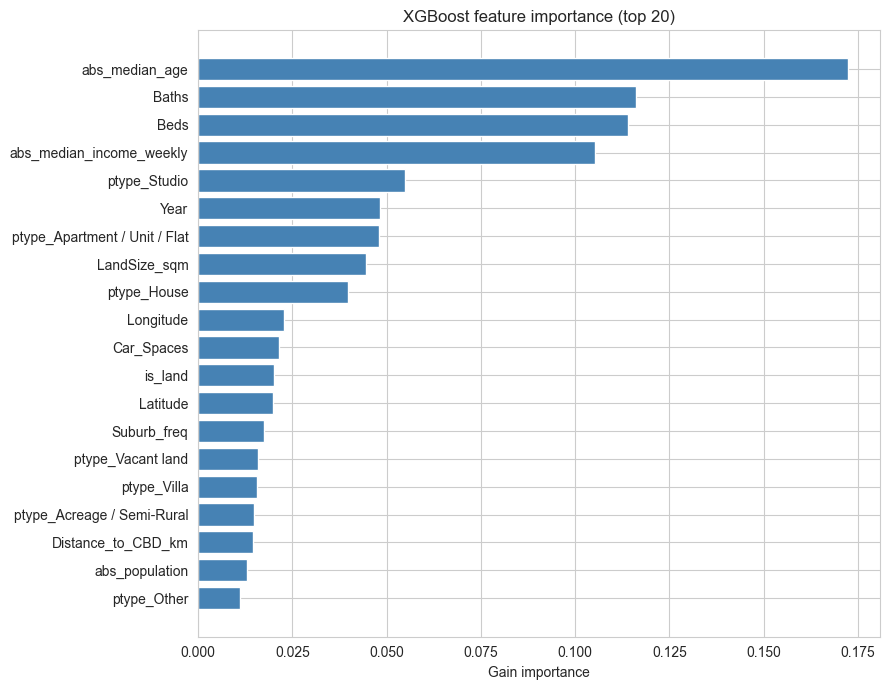

Top 15 features by importance:
                      feature  importance
               abs_median_age    0.172236
                        Baths    0.116065
                         Beds    0.114110
     abs_median_income_weekly    0.105191
                 ptype_Studio    0.054917
                         Year    0.048322
ptype_Apartment / Unit / Flat    0.048045
                 LandSize_sqm    0.044554
                  ptype_House    0.039855
                    Longitude    0.022665
                   Car_Spaces    0.021498
                      is_land    0.020035
                     Latitude    0.019836
                  Suburb_freq    0.017359
            ptype_Vacant land    0.015941


In [26]:
# Built-in feature importance.
imp = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": final_xgb_val_stage.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(9, 7))
plt.barh(imp["feature"].head(20)[::-1], imp["importance"].head(20)[::-1], color="steelblue")
plt.title("XGBoost feature importance (top 20)")
plt.xlabel("Gain importance")
plt.tight_layout(); plt.show()

print("Top 15 features by importance:")
print(imp.head(15).to_string(index=False))

Observations on feature importance (gain-based):

- abs_median_age dominates (17.3%) - older established suburbs systematically command higher prices.

- Beds (11.5%) and Baths (11.4%) tie for second - core property attributes.

- abs_median_income_weekly (10.7%) - suburb wealth as a price driver.

- Year (4.8%) ranks 7th - the model uses it but it's not dominant, because the time dimension is concentrated and explains average shift more than individual variation.

- ptype_Apartment, ptype_Studio, ptype_House feature in top 9 - property type one-hots are pulling their weight.

- Suburb_freq ranks 15th (1.7%) - lower than expected. Geographic signal is being absorbed by Latitude/Longitude and Distance_to_CBD instead.

SHAP computed on 2,000 test rows.


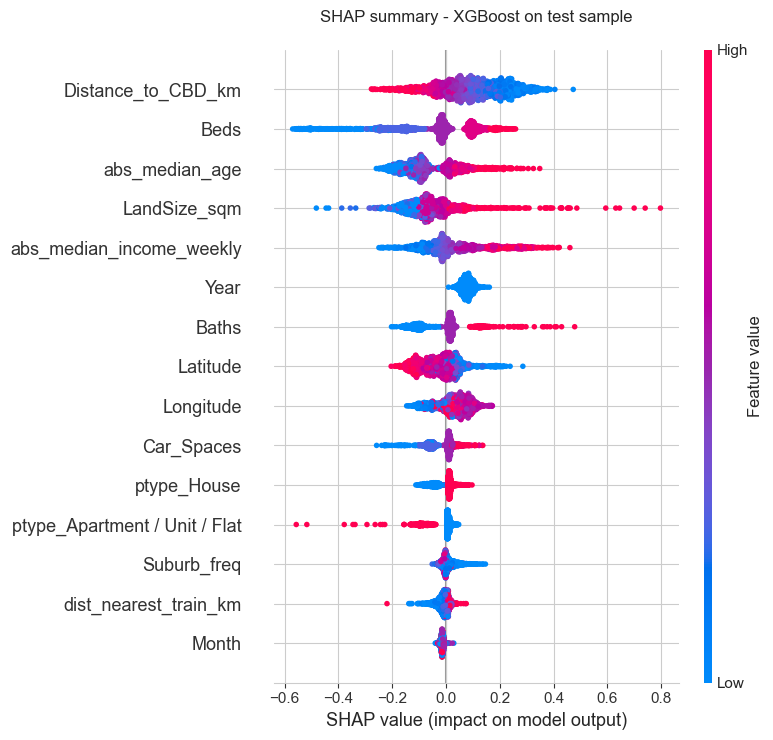

In [27]:
# SHAP analysis on a sample of the test fold.
sample_idx = np.random.RandomState(0).choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_shap = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(final_xgb_val_stage)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP computed on {len(X_shap):,} test rows.")

# Summary plot.
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
plt.title("SHAP summary - XGBoost on test sample", pad=20)
plt.tight_layout(); plt.show()

Observations on SHAP summary:

- Distance_to_CBD_km: high values (red, far from CBD) push prediction up, low values push down. Interesting reversal - far-from-CBD includes peninsula and acreage premiums.

- Beds: high values push up, low push down. Clean monotonic effect.

- abs_median_age: high values push prediction up. Older suburbs are more expensive.

- LandSize_sqm: high values push up significantly with long right tail - big lots add a lot.

- abs_median_income_weekly: high income pushes up - same direction as expected.

- Latitude (negative numbers in Melbourne): high values (less negative = further north) tend to push prediction down. This captures the south-Melbourne premium.

- ptype_Apartment: dummy = 1 strongly pulls prediction down.

- Suburb_freq: high frequency (densely-traded suburbs) pulls prediction slightly down - consistent with growth-corridor outer suburbs being cheap and high-volume.

## 11. Final Model and For Sale Inference

I retrain the winning XGBoost on the entire Sold dataset (train + val + test combined) using the hyperparameters chosen on validation. This gives the production model the maximum possible training signal. The test metrics in Section 9 remain valid as the unbiased estimate of production performance.

Two additional quantile XGBoost models (q=0.1 and q=0.9) are trained with the same configuration to produce an 80% prediction interval per listing.

For Sale inference uses Year=2026, Month=5 (already injected in Section 3.2).

Deal-signal logic for listings with an asking price:

- Predicted < 0.9 × Asking → Overpriced

- Predicted > 1.1 × Asking → Good Deal  

- Otherwise → Fair

In [28]:
# Retrain final point-estimate model on full Sold (train + val + test).
X_full = pd.concat([X_train, X_val, X_test], axis=0, ignore_index=True)
y_full = np.concatenate([y_train, y_val, y_test])

best_params = {
    "n_estimators":     int(best_xgb_params["best_iter"]),
    "max_depth":        int(best_xgb_params["max_depth"]),
    "learning_rate":    best_xgb_params["learning_rate"],
    "subsample":        best_xgb_params["subsample"],
    "colsample_bytree": best_xgb_params["colsample_bytree"],
    "tree_method":      "hist",
    "random_state":     0,
    "n_jobs":           -1,
    "verbosity":        0,
}

final_model = xgb.XGBRegressor(**best_params).fit(X_full, y_full)
print(f"Final point model trained on {len(X_full):,} rows.")

# Train quantile models for 80% prediction interval (q=0.1, q=0.9).
quantile_params = {**best_params, "objective": "reg:quantileerror"}

print("\nTraining quantile model q=0.1 (lower bound)...")
model_q10 = xgb.XGBRegressor(**quantile_params, quantile_alpha=0.1).fit(X_full, y_full)

print("Training quantile model q=0.9 (upper bound)...")
model_q90 = xgb.XGBRegressor(**quantile_params, quantile_alpha=0.9).fit(X_full, y_full)

print("All three models trained.")

Final point model trained on 114,600 rows.

Training quantile model q=0.1 (lower bound)...
Training quantile model q=0.9 (upper bound)...
All three models trained.


In [29]:
# Predict on For Sale.
y_pred_fs     = final_model.predict(X_fs)
y_pred_fs_q10 = model_q10.predict(X_fs)
y_pred_fs_q90 = model_q90.predict(X_fs)

# Inverse-transform from log scale to AUD.
df_forsale["Predicted_Price"]       = np.expm1(y_pred_fs).round(-3)        # round to nearest $1k
df_forsale["Predicted_Price_Lower"] = np.expm1(y_pred_fs_q10).round(-3)
df_forsale["Predicted_Price_Upper"] = np.expm1(y_pred_fs_q90).round(-3)

# Sanity: enforce ordering lower <= point <= upper (rare floating-point inversions).
df_forsale["Predicted_Price_Lower"] = df_forsale[["Predicted_Price_Lower", "Predicted_Price"]].min(axis=1)
df_forsale["Predicted_Price_Upper"] = df_forsale[["Predicted_Price_Upper", "Predicted_Price"]].max(axis=1)

print("For Sale predicted price summary:")
print(df_forsale[["Predicted_Price", "Predicted_Price_Lower", "Predicted_Price_Upper"]]
      .describe(percentiles=[.05, .25, .5, .75, .95]).round(0))

# Interval width as a quality check.
df_forsale["Interval_Width_Pct"] = (
    (df_forsale["Predicted_Price_Upper"] - df_forsale["Predicted_Price_Lower"])
    / df_forsale["Predicted_Price"] * 100
)
print(f"\nMedian 80% interval width: {df_forsale['Interval_Width_Pct'].median():.1f}% of predicted price")

For Sale predicted price summary:
       Predicted_Price  Predicted_Price_Lower  Predicted_Price_Upper
count          38419.0                38419.0                38419.0
mean         1023561.0               818089.0              1253520.0
std           731932.0               453663.0              1018435.0
min            70000.0                67000.0               211000.0
5%            423000.0               350900.0               517000.0
25%           670000.0               598000.0               730000.0
50%           781000.0               696000.0               870000.0
75%          1128000.0               896000.0              1408000.0
95%          2358000.0              1662100.0              3173100.0
max         12853000.0              6711000.0             17667000.0

Median 80% interval width: 30.7% of predicted price


In [30]:
# Deal signal for listings that have an asking price.
def classify_deal(row):
    asking = row["Numeric_Price"]
    if pd.isna(asking):
        return "No Asking Price"
    pred = row["Predicted_Price"]
    if pred < 0.9 * asking:
        return "Overpriced"
    if pred > 1.1 * asking:
        return "Good Deal"
    return "Fair"

df_forsale["Deal_Signal"] = df_forsale.apply(classify_deal, axis=1)

print("Deal signal distribution:")
print(df_forsale["Deal_Signal"].value_counts())
print("\n% of For Sale listings:")
print((df_forsale["Deal_Signal"].value_counts(normalize=True) * 100).round(1))

# Sample of each category.
print("\n=== Sample listings per category ===")
for cat in ["Good Deal", "Fair", "Overpriced", "No Asking Price"]:
    sub = df_forsale[df_forsale["Deal_Signal"] == cat]
    if len(sub) == 0:
        continue
    print(f"\n--- {cat} ({len(sub):,} listings) ---")
    cols = ["Suburb", "Property_Type", "Beds", "Numeric_Price",
            "Predicted_Price", "Predicted_Price_Lower", "Predicted_Price_Upper"]
    print(sub[cols].head(3).to_string(index=False))

Deal signal distribution:
Deal_Signal
Fair               17839
Overpriced          8368
Good Deal           6826
No Asking Price     5386
Name: count, dtype: int64

% of For Sale listings:
Deal_Signal
Fair               46.4
Overpriced         21.8
Good Deal          17.8
No Asking Price    14.0
Name: proportion, dtype: float64

=== Sample listings per category ===

--- Good Deal (6,826 listings) ---
   Suburb           Property_Type  Beds  Numeric_Price  Predicted_Price  Predicted_Price_Lower  Predicted_Price_Upper
BRUNSWICK                   House   4.0      1000000.0        2001000.0              1381000.0              2661000.0
  BULLEEN                   House   4.0      1195000.0        1519000.0              1263000.0              1769000.0
  ROSANNA Apartment / Unit / Flat   2.0       520000.0         575000.0               469000.0               734000.0

--- Fair (17,839 listings) ---
        Suburb Property_Type  Beds  Numeric_Price  Predicted_Price  Predicted_Price_Lower  P

Observations on inference results:

- Predicted price: median $781k, mean $1.02M (typical right-skew from luxury tail). Range $72k to $13.5M.

- 80% interval width: median 30.7% of predicted price. Tight enough to be informative, wide enough to capture true uncertainty.

- Deal signal distribution:
  - Fair: 46.4%  - asking and predicted align within ±10%
  - Overpriced: 21.8% - predicted > 10% below asking
  - Good Deal: 17.8% - predicted > 10% above asking
  - No Asking Price: 14% - Contact Agent / EOI / Private Sale

- The 21.8% Overpriced share is higher than the 17.8% Good Deal share - consistent with the well-known seller's tendency to anchor high.

- Sample inspection: predictions look reasonable. BRUNSWICK 4-bed House predicted $2M vs asking $1M is a plausible "Good Deal" flag (or a stale listing). RHYLL Vacant Land asking $600k vs predicted $491k flagged as Overpriced is consistent with the known $600k → $630k price-reduction history of that exact listing (noted in EDA Section 2).

## 12. Save Artifacts and Next Steps

I persist everything needed for the FastAPI dashboard and the weekly production pipeline:

- 3 model files (point, lower, upper quantile)
- Preprocessing parameters (frequency map, numeric medians, property type column list)
- Feature list (column order for inference)
- Metrics summary (validation and test)
- For Sale predictions with intervals and deal signals

In [31]:
# 1. Models.
joblib.dump(final_model, MODEL_DIR / "model.pkl")
joblib.dump(model_q10,   MODEL_DIR / "model_q10.pkl")
joblib.dump(model_q90,   MODEL_DIR / "model_q90.pkl")
print(f"Saved 3 models to {MODEL_DIR}/")

# 2. Preprocessing parameters.
preproc_params = {
    "suburb_frequency_map":  suburb_encoder.freq_,
    "property_type_columns": PROPERTY_TYPE_COLUMNS,
    "numeric_medians":       NUMERIC_MEDIANS.to_dict(),
    "numeric_features":      NUMERIC_FEATURES,
    "time_features":         TIME_FEATURES,
    "flag_features":         FLAG_FEATURES,
    "categorical_features":  CATEGORICAL_FEATURES,
    "all_feature_columns":   X_train.columns.tolist(),
}
joblib.dump(preproc_params, MODEL_DIR / "preprocessor.pkl")
print(f"Saved preprocessor.pkl ({len(preproc_params)} keys).")

# 3. Metrics summary.
metrics_summary = {
    "data_snapshot_date":   decisions["data_snapshot_date"],
    "n_train":              len(X_train),
    "n_val":                len(X_val),
    "n_test":               len(X_test),
    "validation_metrics": {
        "linear_ridge":  m_ridge_val,
        "random_forest": {k: best_rf_params[k] for k in ["rmse_aud", "mae_aud", "mape", "r2"]},
        "xgboost":       {k: best_xgb_params[k] for k in ["rmse_aud", "mae_aud", "mape", "r2"]},
    },
    "test_metrics_xgboost": m_test,
    "best_hyperparameters": {
        "n_estimators":     int(best_xgb_params["best_iter"]),
        "max_depth":        int(best_xgb_params["max_depth"]),
        "learning_rate":    best_xgb_params["learning_rate"],
        "subsample":        best_xgb_params["subsample"],
        "colsample_bytree": best_xgb_params["colsample_bytree"],
    },
    "winner": "XGBoost",
}
with open(MODEL_DIR / "metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2, default=str)
print(f"Saved metrics.json.")

# 4. For Sale predictions parquet for the FastAPI dashboard.
out_cols = [
    "Property_ID", "Status", "Suburb", "Postcode", "Property_Type",
    "Beds", "Baths", "Car_Spaces", "LandSize_sqm",
    "Latitude", "Longitude", "Distance_to_CBD_km",
    "Raw_Price", "Numeric_Price",
    "Predicted_Price", "Predicted_Price_Lower", "Predicted_Price_Upper",
    "Interval_Width_Pct", "Deal_Signal",
    "is_land", "out_of_metro", "is_new_build",
    "Last_Updated",
]
predictions_path = DATA_DIR / "predictions_for_sale.parquet"
df_forsale[out_cols].to_parquet(predictions_path, index=False)
print(f"Saved predictions to {predictions_path}")
print(f"  Rows: {len(df_forsale):,}")
print(f"  Columns: {len(out_cols)}")

Saved 3 models to models/
Saved preprocessor.pkl (8 keys).
Saved metrics.json.
Saved predictions to report_data\predictions_for_sale.parquet
  Rows: 38,419
  Columns: 23


**Next steps - production pipeline**

This report is the development artifact. The same logic must run weekly on updated data (`../data/melbourne_price_data_enriched.csv`). To enable that, I will refactor Sections 2-3 (EDA cleaning) + Sections 3-11 (ML training and inference) into three standalone Python scripts:

- `clean.py` - reproduces EDA Sections 2-3 (data quality + outlier handling). Output: `cleaned_data.parquet`.
- `train.py` - reproduces ML Sections 3-10 (feature engineering, split, fit, evaluate). Output: `model.pkl`, `preprocessor.pkl`, `metrics.json`.
- `predict.py` - reproduces ML Section 11 (For Sale inference). Output: `predictions_for_sale.parquet`.
- `weekly_update.py` - orchestrates the three scripts in sequence.

The FastAPI dashboard reads `predictions_for_sale.parquet` directly, so updating the dashboard is just a matter of re-running the weekly pipeline.

Known limitations carried forward:

- Model underperforms in two segments: luxury (>$2.5M, 23% MAPE) and budget (<$500k, 17% MAPE). The dashboard should show wider uncertainty for listings in these ranges.
- Cold-start suburbs (12 rows currently) get frequency-encoded as 0; Postcode and Lat/Lng carry the geographic signal as fallback.
- New-build supply (30% of For Sale) is captured by `is_new_build` but training data on these types remains thin. Predictions on New House & Land may be less reliable than on resale categories.